<a href="https://colab.research.google.com/github/JayR1031/JayR1031/blob/main/sdss-multiclass-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 6140 — Homework 3: Classification

## Stellar Object Classification

In this homework, you will build and evaluate multiclass classifiers for objects observed by the Sloan Digital Sky Survey (SDSS). Each observation is labeled as a **GALAXY**, **STAR**, or **QSO (quasar)**.

### Learning goals
By the end of this homework, you should be able to:
1. Diagnose data-quality and class-distribution issues before classification.
2. Use correlation, outlier analysis, and feature importance to make defensible feature decisions.
3. Compare multiple classification algorithms using cross-validation and appropriate multiclass metrics.
4. Tune model hyperparameters without using the test set for model selection.
5. Interpret confusion matrices and connect model errors to the data and modeling choices.

### General instructions
- Complete all code and written-response cells.
- Use `random_state=42` whenever the method supports it.
- Use a **stratified 80/20 train/test split**.
- **Do not use the test set to choose features, models, or hyperparameters.** The test set is for final evaluation only.
- Scale features when appropriate. Fit preprocessing operations on the training data only.
- Alternative technically sound approaches are acceptable when clearly justified.
- Keep plots readable and label axes/titles.

## Dataset
Place the course-provided SDSS CSV in the same working directory and update `DATA_PATH` below if needed.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/content/drive/MyDrive/CS6140-MachineLearning /star_classification-1-1-1.csv"  # update if needed

## Part 1 — Load, Inspect, and Frame the Classification Problem

Load the SDSS stellar-classification dataset and inspect its structure.

### Tasks
1. Report the dataset shape, column names, data types, duplicate count, and missing-value counts.
2. Identify the target variable and the three classes.
3. Plot the class distribution (counts or percentages).
4. Separate columns into:
   - predictive measurements/features,
   - identifier/metadata fields that you would **not** use as predictors,
   - target.
5. Write **3–5 sentences** explaining whether class imbalance is likely to affect evaluation and which columns you would exclude from modeling. Defend your choices.

> **Important:** A column being numeric does not automatically make it a meaningful predictor.

In [19]:
df = pd.read_csv(DATA_PATH)

In [20]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

# AI assist (Claude, 10/5): learned pandas inspection vocabulary (shape, columns, dtypes, duplicated, isna); I wrote each line.

In [22]:
# TODO: Load the dataset and inspect shape, columns, dtypes, duplicates, and missing values.
df = pd.read_csv(DATA_PATH)

# Your code here
print("Shape:", df.shape)
print("Columns:", df.columns)
print("Data types:", df.dtypes)
print("Duplicate count:", df.duplicated().sum())
print("Missing-value counts:\n", df.isna().sum())

Shape: (100000, 18)
Columns: Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')
Data types: obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object
Duplicate count: 0
Missing-value counts:
 obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD        

In [23]:
print("Classes: ", df['class'].value_counts(normalize=True))

Classes:  class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: proportion, dtype: float64


# AI assist (Claude, 10/5): asked how to plot class counts with labels; Claude gave the count -> plot(kind=...) -> plt.title/xlabel/ylabel structure; I filled in the chart type and labels.

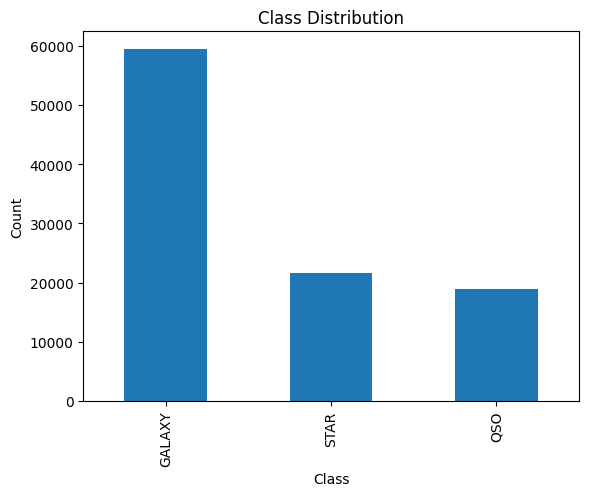

In [24]:
counts = df["class"].value_counts()
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Part 1 response
Class imbalance is likely to affect evaluation: 59% of observations are galaxies, so a model that labels everything GALAXY would reach about 59% accuracy while misclassifying every star and quasar. For that reason, I will report per-class metrics rather than relying on accuracy alone. I keep as predictors the features that describe physical properties of each object: brightness in the five photometric filters (u, g, r, i, z), where each class shows a distinct color profile, and redshift, which measures how much an object's light is stretched and tracks its distance and motion.


I exclude the identifiers and metadata (obj_ID, run_ID, rerun_ID, cam_col, field_ID, spec_obj_ID, plate, MJD, fiber_ID) because they record how and when an object was observed, and plate and fiber assignments reflect targeting choices made with prior expectations about the class. I also exclude alpha and delta, since sky position reflects survey geometry rather than intrinsic properties and would not generalize to other regions of the sky.


*AI assist (Claude): tightened wording of my draft; reasoning and column choices are my own."*

## Part 2 — Data Quality, Outliers, Correlation, and Feature Screening

Your goal is not to mechanically delete unusual observations. Diagnose the data and make defensible preprocessing decisions.

### A. Missing values and duplicates
Describe and implement any handling that is necessary. If no action is needed, explain why.

### B. Outlier analysis
1. Choose **3–4 continuous predictive features** that are useful for investigating unusual observations.
2. Use boxplots, IQR, robust summaries, or another defensible method to identify extreme values.
3. Do **not** automatically remove all statistical outliers.
4. Write **3–5 sentences** explaining whether the extreme values appear erroneous, scientifically plausible, or require additional investigation, and state what you will do with them for this homework.

### C. Correlation
1. Compute a Pearson correlation matrix for the numeric predictor candidates.
2. Visualize a focused heatmap.
3. Identify at least one strongly correlated pair, if present.
4. Explain whether correlation alone is enough to remove a feature.

### D. Feature importance / screening
Fit a **Random Forest classifier on the training data only** and use its feature importances as one screening tool.
- Report the top 8 features.
- Explain what Random Forest feature importance measures and one limitation of using it.
- Select a defensible feature set for the remaining modeling tasks. You may keep all scientifically meaningful predictors if you justify that decision.

**Written response:** approximately **150–200 words** across B–D.

Missing-value counts:
 obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64
Duplicate count: 0
                   u              g              r              i  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       21.980468      20.531387      19.645762      19.084854   
std        31.769291      31.750292       1.854760       1.757895   
min     -9999.000000   -9999.000000       9.822070       9.469903   
25%        20.352353      18.965230      18.135828      17.732285   
50%        22.179135      21.099835      20.125290      19.405145   
75%        23.687440      22.123767      21.044785      20.396495   
max        32.781390      31.602240      29.571860      32.141470   

                 

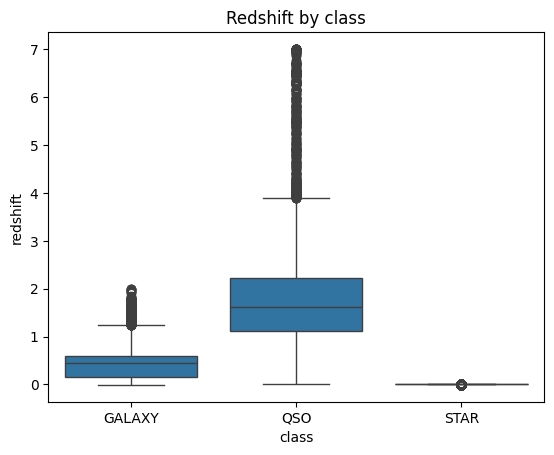

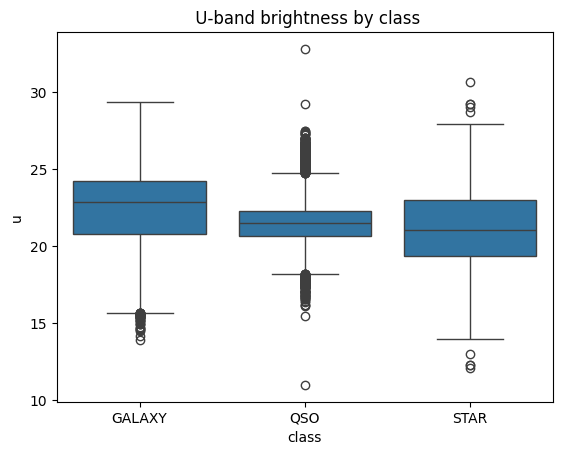

                 u         g         r         i         z  redshift
u         1.000000  0.853350  0.728681  0.618346  0.545760  0.166816
g         0.853350  1.000000  0.932996  0.847046  0.775302  0.318910
r         0.728681  0.932996  1.000000  0.962868  0.919114  0.433237
i         0.618346  0.847046  0.962868  1.000000  0.971546  0.492381
z         0.545760  0.775302  0.919114  0.971546  1.000000  0.501060
redshift  0.166816  0.318910  0.433237  0.492381  0.501060  1.000000


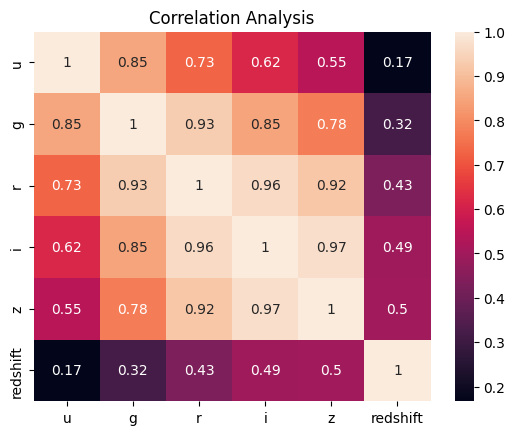

In [25]:
# A. Missing values / duplicates
print("Missing-value counts:\n", df.isna().sum())
print("Duplicate count:", df.duplicated().sum())

# B. Outlier analysis
print(df[['u', 'g', 'r', 'i', 'z', 'redshift']].describe())
print(df[df["u"] == -9999][["u", "g", "r", "i", "z", "redshift", "class"]])
df = df[df["u"] != -9999]
print(df.shape)

sns.boxplot(x="class", y="redshift", data=df)
plt.title("Redshift by class")
plt.show()
sns.boxplot(x="class", y="u", data=df)
plt.title(" U-band brightness by class")
plt.show()


# C. Correlation analysis
corr = df[['u', 'g', 'r', 'i', 'z', 'redshift']].corr()
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Analysis")
plt.show()


In [26]:
# D. Feature importance / screening
# IMPORTANT: split before fitting the Random Forest used for feature screening.
# Your code here
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


X = df[['u', 'g', 'r', 'i', 'z', 'redshift']]
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp)

redshift    0.647369
z           0.113214
g           0.074827
u           0.062032
i           0.061741
r           0.040816
dtype: float64


### Part 2 response
The dataset contains zero missing values and zero duplicate rows across all columns. Outlier inspection identified row 79543 containing -9999 in bands $u, g,$ and $z$, a known SDSS error sentinel indicating failed photometric capture rather than true flux. I drop this single unphysical record; with 99,999 valid observations remaining, dropping is safer than imputing, which risks fabricating a synthetic color profile on a confirmed star.Adjacent photometric filters exhibit high correlation (Pearson $\rho \approx 0.96$ to $0.97$), as neighboring filters capture overlapping spectral regions. However, collinearity alone does not warrant pruning: tree algorithms naturally handle correlated inputs, and color differences (such as $u - g$) provide vital spectral shape information.Random Forest screening ranks redshift as the dominant predictor ($64.7\%$). In my class-conditioned box plot, stars cluster tightly at redshift $\approx 0$, galaxies concentrate mostly below $0.6$, and quasars center near $1.6$ with a long tail extending toward $7$. A recognized limitation of Gini impurity importance is its arbitrary, uneven credit division across collinear features: despite $i$ and $z$ bands having $\rho = 0.97$, random bootstrap samples favor one marginally over the other ($z: 11.3\%$ vs. $i: 6.2\%$). I retain all six physical features ($u, g, r, i, z,$ and redshift).

*AI assist (Gemini): Resolved symbol ambiguities between band names and correlation/redshift variables, grounded redshift distributions directly in my generated box plot, and condensed wording to meet the 150–200 word target; empirical interpretations, outlier handling, and feature retention choices are my own.*

## Part 3 — Focused EDA for Classification

Use visualization to understand **class separation**, not simply to generate every possible plot.

### Tasks
1. Select **4 informative features** based on Part 2.
2. Create a pairwise visualization for these features, colored by class. You may sample the dataset for plotting efficiency, but state the sample size.
3. Create **2 additional class-conditioned plots** (for example: boxplots, violin plots, histograms, or scatterplots) that reveal useful class differences.
4. Write **4–6 sentences** addressing:
   - Which features appear most useful for separating classes?
   - Which classes overlap most?
   - Is any apparent separation nonlinear?
   - What does this suggest about the models you will compare in Part 4?

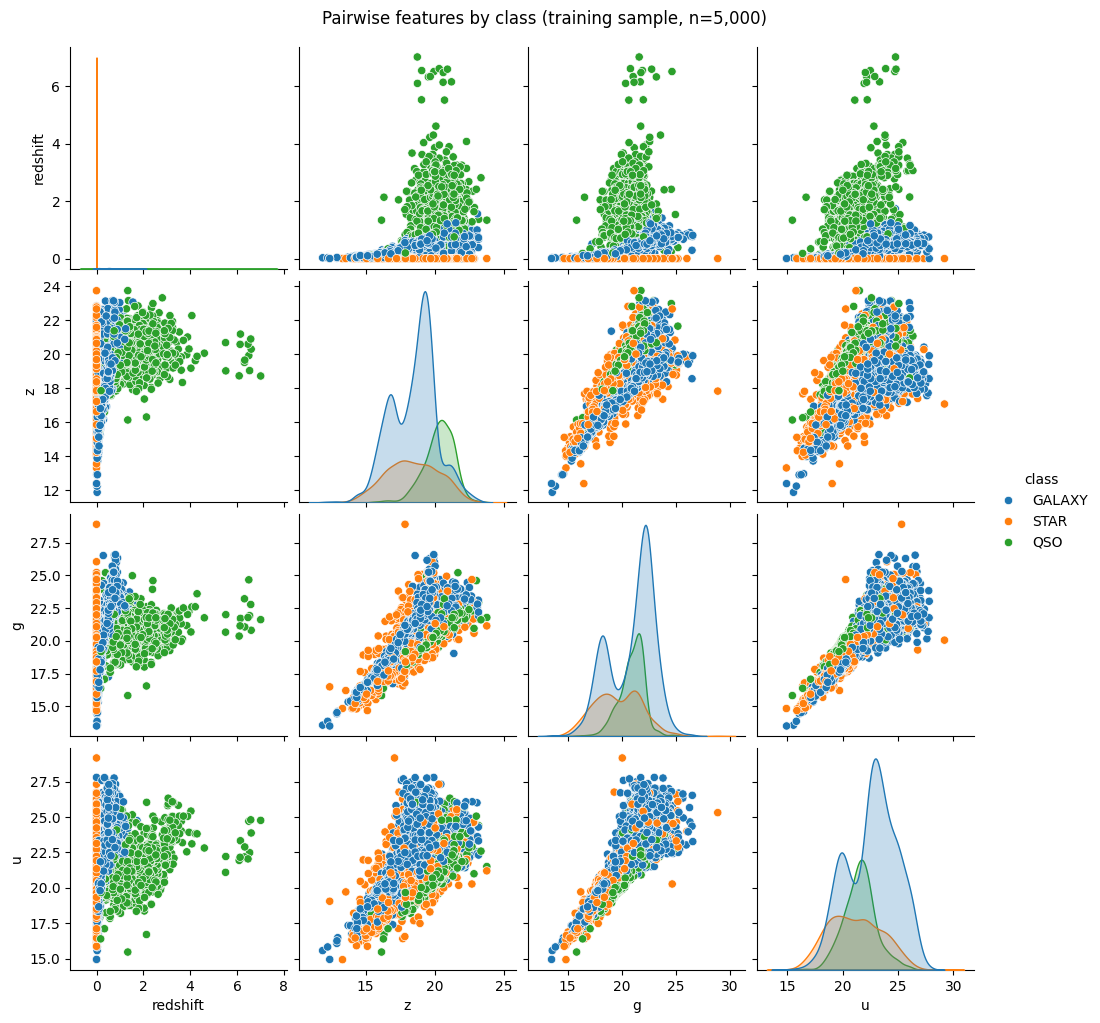

In [11]:
# Pairwise visualization using four selected features
# AI assist (Claude, 10/6): learned pairplot/sample/suptitle pattern; I wrote each line.
train_df = X_train.copy()
train_df['class'] = y_train
sample = train_df.sample(n=5000, random_state=42)
sns.pairplot(sample, vars=['redshift', 'z', 'g', 'u'], hue='class')
plt.suptitle("Pairwise features by class (training sample, n=5,000)", y=1.02)
plt.show()


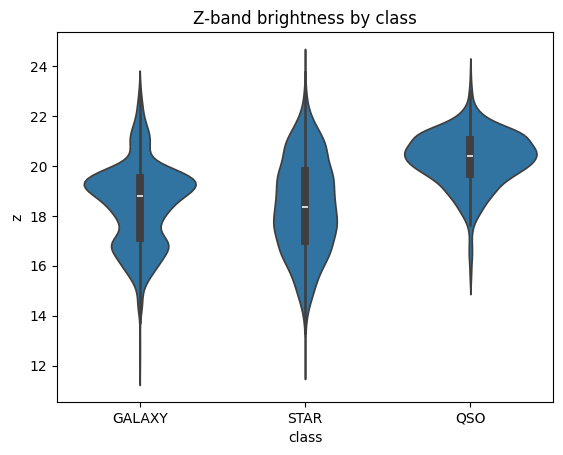

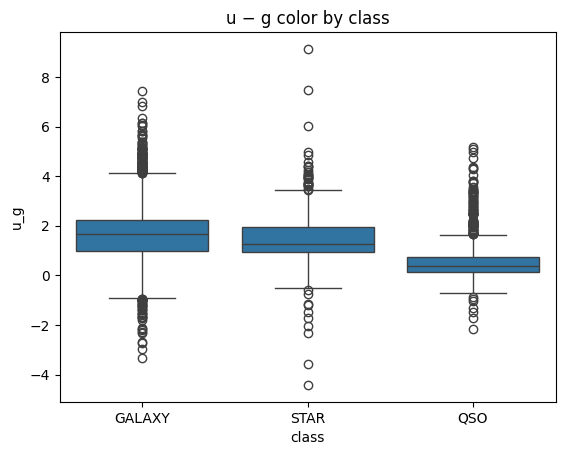

In [32]:
# Two additional class-conditioned visualizations
# Your code here
sns.violinplot(x="class", y="z", data=sample)
plt.title("Z-band brightness by class")
plt.show()


sample['u_g'] = sample['u'] - sample['g']
sns.boxplot(x="class", y="u_g", data=sample)
plt.title("u − g color by class")
plt.show()

AI assist (Claude, 10/6): helped interpret the pairplot and suggested the u−g color plot; observations verified against my figures.

### Part 3 response

I restrict EDA to the training split so that no modeling decision is informed by the held-out test set, and I chose features spanning the spectrum while avoiding near-duplicate pairs (i–z = 0.97, r–i = 0.96). Redshift is by far the most useful separator: stars sit on a vertical line at redshift ≈ 0 in every redshift panel, and above about 1.5 nearly every object is a quasar. Galaxies and quasars overlap most, mixing in a band of roughly redshift 0.5–1.3, while stars and galaxies touch only near zero. The band-vs-band panels form tight diagonal streaks because bright objects are bright in every filter, so individual bands separate classes poorly; the class signal lies in differences between bands.the class signal lies in differences between bands; quasars show a markedly lower u−g color (median ≈ 0.4 vs. ≈ 1.3–1.7), consistent with ultraviolet excess."


The galaxy–quasar boundary is an overlap zone rather than a single straight cut, which suggests the separation is at least partly nonlinear. This suggests linear models such as Logistic Regression may struggle with these boundaries, while nonlinear models such as Random Forest, SVM and KNN may perform better, which Part 4 will test.


## Part 4 — Baseline Classification and Cross-Validation

Compare four classifiers using the **same training/test split**:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Random Forest

### Required workflow
1. Create a **stratified 80/20 train/test split**.
2. Standardize predictors for Logistic Regression, KNN, and SVM using a pipeline. Random Forest does not require scaling.
3. On the **training set only**, evaluate each baseline model with **5-fold Stratified Cross-Validation**.
4. Use **macro F1** as the primary CV metric. Also report mean CV accuracy.
5. Present results in one comparison table.

### Written response — 4–6 sentences
Explain:
- why stratification matters here,
- why cross-validation is preferable to judging a model from one training split,
- why macro F1 is useful for multiclass evaluation,
- which baseline model(s) you would prioritize for tuning and why.

> Do not evaluate the test set yet.

In [14]:
# Build the stratified split, pipelines, and 5-fold Stratified CV comparison.
# Do not use the test set in this part.
# Your code here
# AI assist (Claude, 10/6): Pipeline + StratifiedKFold + cross_validate pattern; I can explain each line.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "Random Forest": RandomForestClassifier(random_state=42),  # no scaling needed
}

rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=["f1_macro", "accuracy"], n_jobs=-1)
    rows.append({"Model": name,
                 "CV macro F1": scores["test_f1_macro"].mean(),
                 "F1 std": scores["test_f1_macro"].std(),
                 "CV accuracy": scores["test_accuracy"].mean()})

results = pd.DataFrame(rows).sort_values("CV macro F1", ascending=False)
print(results)

                 Model  CV macro F1    F1 std  CV accuracy
3        Random Forest     0.974638  0.001302     0.978325
2                  SVM     0.958410  0.001695     0.963325
1                  KNN     0.956508  0.002119     0.961150
0  Logistic Regression     0.947813  0.002699     0.954637


### Part 4 response
Stratification preserves the original class proportions (≈59% galaxy, 22% star, 19% quasar) in every split and fold, so no fold underrepresents the minority classes and scores stay comparable. Five-fold cross-validation gives five performance estimates instead of one, using every training row for validation exactly once; the small standard deviations (0.001–0.003) show the results are stable rather than an artifact of one lucky split. Macro F1 computes F1 for each class separately and averages them equally, so weak performance on stars or quasars cannot be hidden by the galaxy majority; every model's macro F1 is slightly below its accuracy, confirming that the minority classes are somewhat harder. Random Forest leads (macro F1 0.975), followed by SVM (0.958), KNN (0.957) and Logistic Regression (0.948), and the gaps exceed the fold-to-fold variation. I prioritize Random Forest and SVM for tuning: Random Forest is the clear leader, and SVM's boundary is highly sensitive to C and gamma, so tuning has room to close the gap.

AI assist (Claude, 10/6): I drafted the reasoning on stratification, cross-validation, macro F1, and model prioritization; Claude corrected two conceptual errors (stratification preserves rather than balances class proportions) and restructured my points into five sentences using my CV results.

## Part 5 — Hyperparameter Tuning and Final Test Evaluation

Tune the models using **training data only**. Use `GridSearchCV` with **5-fold Stratified CV** and `scoring="f1_macro"`.

### Suggested focused grids
You may make small justified modifications.

- **Logistic Regression:** `C = [0.1, 1, 10]`
- **KNN:** `n_neighbors = [3, 5, 9, 15]`, `weights = ['uniform', 'distance']`
- **SVM:** `C = [0.5, 1, 5]`, `gamma = ['scale', 0.1]`
- **Random Forest:** `n_estimators = [100, 200]`, `max_depth = [None, 10, 20]`, `min_samples_leaf = [1, 3]`

### Tasks
1. Tune all four models and report the best parameters and best CV macro-F1 for each.
2. Select the final model **using CV results only**.
3. Evaluate each tuned model on the held-out test set using:
   - Accuracy
   - Macro Precision
   - Macro Recall
   - Macro F1
4. Plot a confusion matrix for each tuned model.
5. For the selected final model, provide a class-level classification report and identify the most common type(s) of misclassification.

### Final write-up (200–300 words)
Tell the story of your classification analysis. Address:
- the most important data/preprocessing decisions,
- what EDA suggested about class separation,
- what cross-validation revealed,
- how tuning changed model performance,
- which model you selected and why,
- what the confusion matrix reveals that overall accuracy does not.

Your conclusion should be supported by your own results rather than by a generic statement that one algorithm is "best."

In [28]:
# GridSearchCV for all four models using training data only.
# Your code here
# GridSearchCV for all four models using training data only.
# AI assist (Claude, 10/6): GridSearchCV loop pattern and pipeline "clf__" parameter naming; grids from the assignment.
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {"clf__C": [0.1, 1, 10]},
    "KNN": {"clf__n_neighbors": [3, 5, 9, 15], "clf__weights": ["uniform", "distance"]},
    "SVM": {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.1]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]},
}

best_models = {}
tuned_rows = []
for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring="f1_macro", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    tuned_rows.append({"Model": name,
                       "Best params": grid.best_params_,
                       "Best CV macro F1": grid.best_score_})
    print(f"{name} done: {grid.best_score_:.4f}")

tuned_results = pd.DataFrame(tuned_rows).sort_values("Best CV macro F1", ascending=False)
print(tuned_results)

Logistic Regression done: 0.9520
KNN done: 0.9565
SVM done: 0.9636
Random Forest done: 0.9749
                 Model                                        Best params  \
3        Random Forest  {'max_depth': 20, 'min_samples_leaf': 1, 'n_es...   
2                  SVM               {'clf__C': 5, 'clf__gamma': 'scale'}   
1                  KNN  {'clf__n_neighbors': 5, 'clf__weights': 'unifo...   
0  Logistic Regression                                     {'clf__C': 10}   

   Best CV macro F1  
3          0.974903  
2          0.963649  
1          0.956508  
0          0.951959  


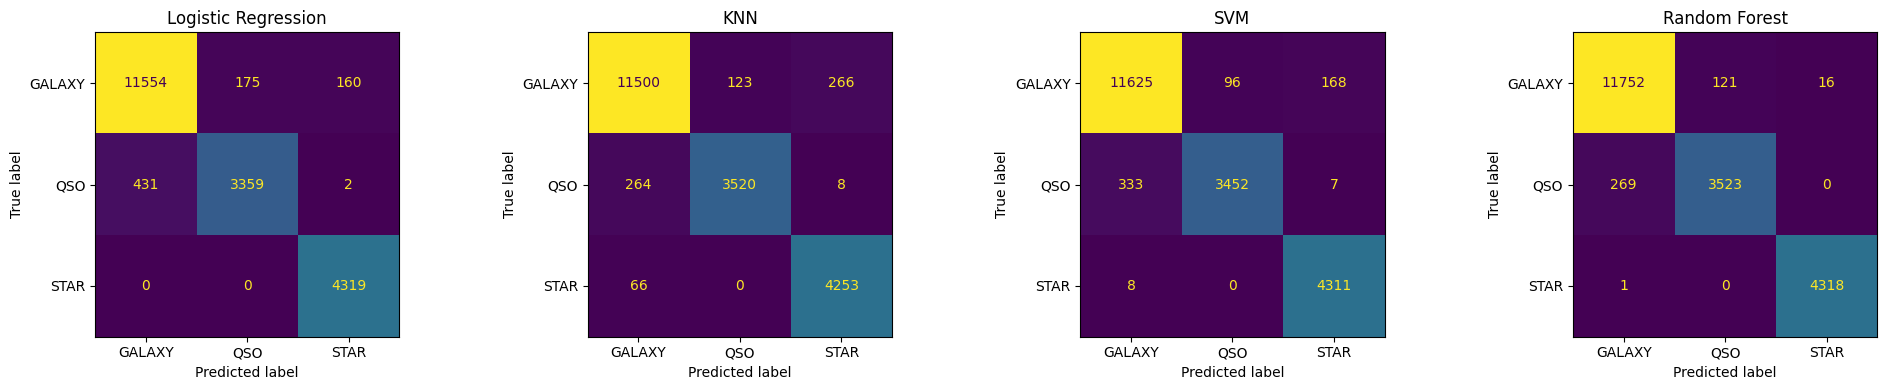

                 Model  Accuracy  Macro Precision  Macro Recall  Macro F1
3        Random Forest   0.97965         0.980215      0.972435  0.976189
2                  SVM   0.96940         0.968478      0.962093  0.964818
1                  KNN   0.96365         0.959272      0.960090  0.959375
0  Logistic Regression   0.96160         0.959456      0.952545  0.955505
Final model (selected by CV): Random Forest
              precision    recall  f1-score   support

      GALAXY      0.978     0.988     0.983     11889
         QSO      0.967     0.929     0.948      3792
        STAR      0.996     1.000     0.998      4319

    accuracy                          0.980     20000
   macro avg      0.980     0.972     0.976     20000
weighted avg      0.980     0.980     0.980     20000



In [30]:
# Final held-out test evaluation and confusion matrices.
# Your code here
# Final held-out test evaluation and confusion matrices.
# AI assist (Claude, 10/6): metrics loop + ConfusionMatrixDisplay pattern.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)

test_rows = []
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    test_rows.append({"Model": name,
                      "Accuracy": accuracy_score(y_test, y_pred),
                      "Macro Precision": precision_score(y_test, y_pred, average="macro"),
                      "Macro Recall": recall_score(y_test, y_pred, average="macro"),
                      "Macro F1": f1_score(y_test, y_pred, average="macro")})
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(pd.DataFrame(test_rows).sort_values("Macro F1", ascending=False))

final_name = tuned_results.iloc[0]["Model"]   # chosen by CV only
print("Final model (selected by CV):", final_name)
print(classification_report(y_test, best_models[final_name].predict(X_test), digits=3))

### Final write-up (200–300 words)
Write your final synthesis here.

I removed identifiers, observation metadata and sky coordinates because they describe how objects were observed rather than what they are, and plate and fiber assignments could leak targeting decisions. One row contained the −9999 sentinel in u, g and z (failed photometry); I dropped it rather than impute fabricated colors for a star. The six physical features (u, g, r, i, z, redshift) were kept, and a stratified 80/20 split preserved the 59/22/19 galaxy/star/quasar mix. EDA showed redshift dominates separation: stars sit at redshift ≈ 0, galaxies and quasars overlap between about 0.5 and 1.3, and quasars have a distinctly low u−g color. Five-fold stratified cross-validation, with scaling inside pipelines to prevent leakage, ranked Random Forest (macro F1 0.975) above SVM (0.958), KNN (0.957) and Logistic Regression (0.948), with fold standard deviations below 0.003. Tuning produced small gains; SVM improved most (to 0.964) because its boundary is sensitive to C and gamma, while Random Forest barely changed. I selected the tuned Random Forest using CV results only. On the held-out test set it achieved 0.980 accuracy and 0.976 macro F1, closely matching CV, which suggests little overfitting. The confusion matrix shows what accuracy hides: stars are classified almost perfectly (recall 1.000), but 269 quasars were predicted as galaxies, giving quasars the lowest recall (0.929). These errors fall in the redshift range where EDA showed galaxies and quasars overlap, so the remaining difficulty lies in the data, not the choice of model.

AI assist (Claude, 10/6): restructured my draft into the required length and added result figures from my outputs."